#Exp 8:
Implement Multiclass Classification models for students
Performance Level analysis and perform comparative analysis.
(Random Forest, Decision Tree, Multinomial Logistic Regression,
XGBoost, K-Nearest Neighbors).

In [10]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle




#Load and Explore Dataset

In [11]:
df = pd.read_csv('/content/drive/MyDrive/AML_Lab_B19/Exp-8 Multiclass Classification/multiclass_classification_dataset_500_samples.csv')

# Basic info
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

# Assume typical student features; adjust if different
print("\nDataset description:")
print(df.describe())


Dataset shape: (500, 8)

Columns: ['Study_Hours', 'Attendance_Percentage', 'Assignment_Score', 'Internal_Marks', 'Participation', 'Internet_Access', 'Previous_Grade', 'Performance_Level']

First 5 rows:
   Study_Hours  Attendance_Percentage  Assignment_Score  Internal_Marks  \
0        22.48                  84.26             86.79           76.68   
1        19.31                  94.09             81.10           56.73   
2        23.24                  61.01             70.72           52.73   
3        27.62                  80.63             62.24           64.95   
4        18.83                  68.49             78.38           62.45   

  Participation Internet_Access Previous_Grade  Performance_Level  
0        Medium             Yes              B                  1  
1           Low             Yes              B                  1  
2        Medium             Yes              A                  0  
3           Low             Yes              C                  0  
4     

#Data Preprocessing - Handle Categorical and Create Target

In [12]:
# Encode categorical columns (adjust column names based on your dataset)
categorical_cols = df.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# Feature engineering: Create multiclass target 'performance_level' from scores (common for student data)
score_cols = [col for col in df.columns if 'score' in col.lower() or 'math' in col.lower() or 'read' in col.lower() or 'writ' in col.lower()]
if len(score_cols) > 0:
    df['avg_score'] = df[score_cols].mean(axis=1)
else:
    df['avg_score'] = df.select_dtypes(include=[np.number]).mean(axis=1)  # Fallback to numeric mean

# Define performance levels (Low: <50, Medium: 50-75, High: >75)
def get_performance_level(score):
    if score < 50:
        return 0  # Low
    elif score < 75:
        return 1  # Medium
    else:
        return 2  # High

df['performance_level'] = df['avg_score'].apply(get_performance_level)

# Target distribution
print("Performance level distribution:")
print(df['performance_level'].value_counts().sort_index())
print("\nTarget value counts:\n", pd.Series(df['performance_level']).value_counts().sort_index())

# Features and target
X = df.drop(['performance_level', 'avg_score'], axis=1)  # Drop derived columns
y = df['performance_level']

print("\nFeatures shape:", X.shape)
print("Target unique classes:", np.unique(y))


Performance level distribution:
performance_level
0     18
1    291
2    191
Name: count, dtype: int64

Target value counts:
 performance_level
0     18
1    291
2    191
Name: count, dtype: int64

Features shape: (500, 8)
Target unique classes: [0 1 2]


#Train-Test Split and Scaling

In [13]:
# Split data (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)


Train shape: (400, 8)
Test shape: (100, 8)


#Train Models and Predict

In [14]:
# Dictionary of models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Multinomial Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss')
}

# Use scaled data for all except tree-based (they handle unscaled well, but consistent)
X_train_dict = {'Decision Tree': X_train, 'Random Forest': X_train, 'XGBoost': X_train,
                'Multinomial Logistic Regression': X_train_scaled, 'KNN': X_train_scaled}
X_test_dict = {'Decision Tree': X_test, 'Random Forest': X_test, 'XGBoost': X_test,
               'Multinomial Logistic Regression': X_test_scaled, 'KNN': X_test_scaled}

predictions = {}
accuracies = {}
f1_scores = {}
cv_scores = {}

for name, model in models.items():
    # Select appropriate data
    if name in ['Decision Tree', 'Random Forest', 'XGBoost']:
        x_tr, x_te = X_train, X_test
    else:
        x_tr, x_te = X_train_scaled, X_test_scaled

    # Train
    model.fit(x_tr, y_train)
    y_pred = model.predict(x_te)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cv = cross_val_score(model, x_tr, y_train, cv=5, scoring='accuracy').mean()

    predictions[name] = y_pred
    accuracies[name] = acc
    f1_scores[name] = f1
    cv_scores[name] = cv

    print(f"{name}: Accuracy={acc:.3f}, F1={f1:.3f}, CV-Acc={cv:.3f}")


Decision Tree: Accuracy=1.000, F1=1.000, CV-Acc=0.997
Random Forest: Accuracy=1.000, F1=1.000, CV-Acc=0.975
Multinomial Logistic Regression: Accuracy=0.960, F1=0.959, CV-Acc=0.948
KNN: Accuracy=0.810, F1=0.791, CV-Acc=0.792
XGBoost: Accuracy=1.000, F1=1.000, CV-Acc=0.993


#Comparative Analysis - Tables and Visuals

Model Comparison Table:
                                 Accuracy  F1-Score (weighted)  \
Decision Tree                        1.00                1.000   
Random Forest                        1.00                1.000   
XGBoost                              1.00                1.000   
Multinomial Logistic Regression      0.96                0.959   
KNN                                  0.81                0.791   

                                 5-Fold CV Accuracy  
Decision Tree                                 0.997  
Random Forest                                 0.975  
XGBoost                                       0.992  
Multinomial Logistic Regression               0.948  
KNN                                           0.792  


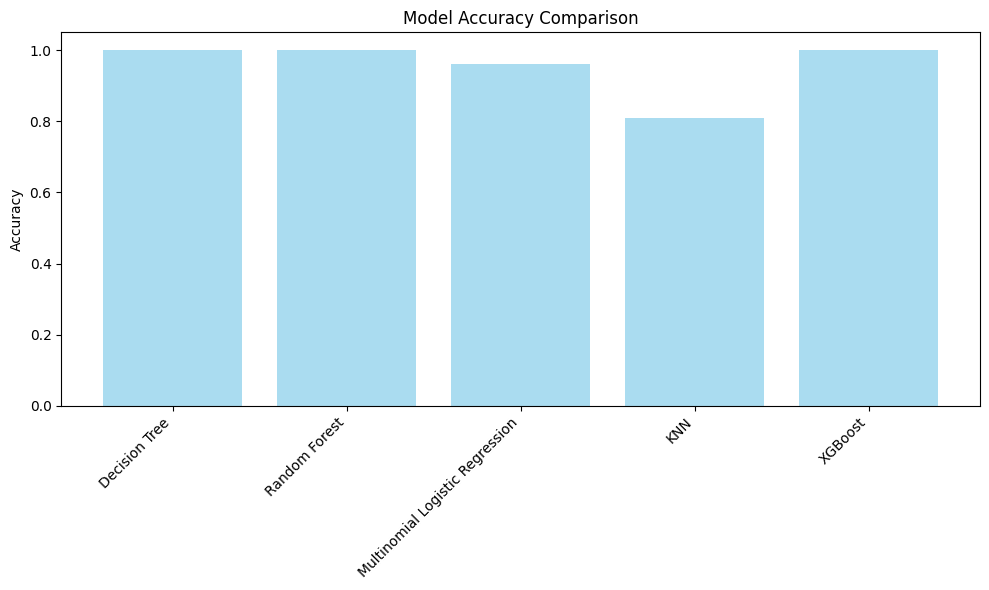


Best model: Decision Tree (Acc: 1.000)


In [15]:
# Results table
results_df = pd.DataFrame({
    'Accuracy': accuracies,
    'F1-Score (weighted)': f1_scores,
    '5-Fold CV Accuracy': cv_scores
}).round(3)
print("Model Comparison Table:")
print(results_df.sort_values('F1-Score (weighted)', ascending=False))

# Plot comparison
plt.figure(figsize=(10, 6))
models_names = list(accuracies.keys())
acc_vals = list(accuracies.values())
plt.bar(models_names, acc_vals, color='skyblue', alpha=0.7)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Best model
best_model = max(accuracies, key=accuracies.get)
print(f"\nBest model: {best_model} (Acc: {accuracies[best_model]:.3f})")


#Detailed Metrics for Best Model

Classification Report (Best Model):
              precision    recall  f1-score   support

     Low (0)       1.00      1.00      1.00         4
  Medium (1)       1.00      1.00      1.00        58
    High (2)       1.00      1.00      1.00        38

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



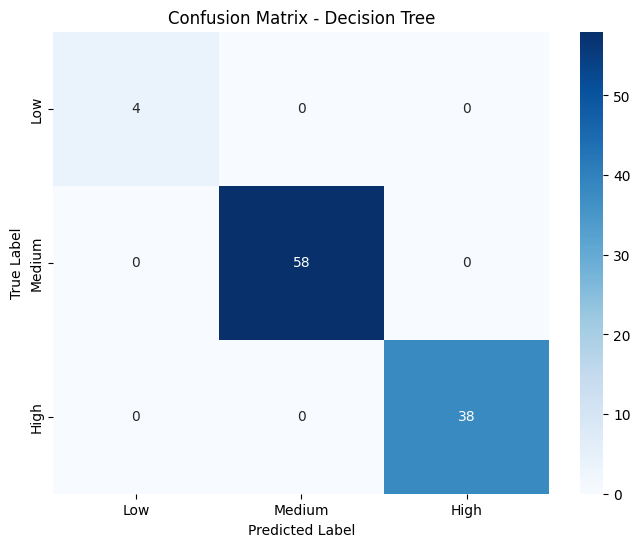

In [16]:
# Detailed report for best model
best_name = best_model
best_pred = predictions[best_name]

if best_name in ['Decision Tree', 'Random Forest', 'XGBoost']:
    best_model_instance = models[best_name]
else:
    # Retrain best model for report
    best_model_instance = models[best_name]
    if best_name in ['Multinomial Logistic Regression', 'KNN']:
        best_model_instance.fit(X_train_scaled, y_train)
        best_pred = best_model_instance.predict(X_test_scaled)
    else:
        best_model_instance.fit(X_train, y_train)
        best_pred = best_model_instance.predict(X_test)

print("Classification Report (Best Model):")
print(classification_report(y_test, best_pred, target_names=['Low (0)', 'Medium (1)', 'High (2)']))

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
